In [8]:
import sys

print(sys.executable)

c:\Users\HP\Documents\flight-delay-prediction\venv\Scripts\python.exe


In [9]:
import pandas as pd 

flights = pd.read_csv("../data/raw/flights.csv")

flights.head()



C:\Users\HP\AppData\Local\Temp\ipykernel_25120\998367148.py:3: DtypeWarning: Columns (0: ORIGIN_AIRPORT, 1: DESTINATION_AIRPORT) have mixed types. Specify dtype option on import or set low_memory=False.
  flights = pd.read_csv("../data/raw/flights.csv")


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
flights.shape


(5819079, 31)

In [11]:
flights.info()

<class 'pandas.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 31 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              str    
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          str    
 7   ORIGIN_AIRPORT       object 
 8   DESTINATION_AIRPORT  object 
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  TAXI_OUT             float64
 13  WHEELS_OFF           float64
 14  SCHEDULED_TIME       float64
 15  ELAPSED_TIME         float64
 16  AIR_TIME             float64
 17  DISTANCE             int64  
 18  WHEELS_ON            float64
 19  TAXI_IN              float64
 20  SCHEDULED_ARRIVAL    int64  
 21  ARRIVAL_TIME         float64
 22  ARRIVAL_DELAY        float64
 23  DIVERTED             int64  
 24  CANCELLED

In [12]:
flights.isna().sum().sort_values(ascending=False)

CANCELLATION_REASON    5729195
LATE_AIRCRAFT_DELAY    4755640
WEATHER_DELAY          4755640
AIRLINE_DELAY          4755640
AIR_SYSTEM_DELAY       4755640
SECURITY_DELAY         4755640
ELAPSED_TIME            105071
AIR_TIME                105071
ARRIVAL_DELAY           105071
WHEELS_ON                92513
TAXI_IN                  92513
ARRIVAL_TIME             92513
WHEELS_OFF               89047
TAXI_OUT                 89047
DEPARTURE_TIME           86153
DEPARTURE_DELAY          86153
TAIL_NUMBER              14721
SCHEDULED_TIME               6
DESTINATION_AIRPORT          0
DAY                          0
DAY_OF_WEEK                  0
AIRLINE                      0
FLIGHT_NUMBER                0
MONTH                        0
ORIGIN_AIRPORT               0
SCHEDULED_DEPARTURE          0
YEAR                         0
SCHEDULED_ARRIVAL            0
DISTANCE                     0
DIVERTED                     0
CANCELLED                    0
dtype: int64

In [13]:
flights.groupby("CANCELLED")["ARRIVAL_DELAY"].apply(lambda x: x.isna().sum())

CANCELLED
0    15187
1    89884
Name: ARRIVAL_DELAY, dtype: int64

In [14]:
flights["CANCELLED"].value_counts()

CANCELLED
0    5729195
1      89884
Name: count, dtype: int64

In [15]:
pd.crosstab(
    flights["CANCELLED"],
    flights["ARRIVAL_DELAY"].isna()
)

ARRIVAL_DELAY,False,True
CANCELLED,,
0,5714008,15187
1,0,89884


In [16]:
flights[
    (flights["CANCELLED"] == 0) &
    (flights["ARRIVAL_DELAY"].isna())
].head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
724,2015,1,1,4,DL,716,N944DL,OMA,ATL,645,...,1451.0,NaN,1,0,NaN,NaN,NaN,NaN,NaN,NaN
1455,2015,1,1,4,OO,5237,N712SK,MKE,IAH,745,...,1505.0,NaN,1,0,NaN,NaN,NaN,NaN,NaN,NaN
2218,2015,1,1,4,WN,1966,N685SW,ATL,JAX,845,...,1219.0,NaN,1,0,NaN,NaN,NaN,NaN,NaN,NaN
2526,2015,1,1,4,EV,4555,N12552,IAH,HRL,902,...,1319.0,NaN,1,0,NaN,NaN,NaN,NaN,NaN,NaN
2866,2015,1,1,4,WN,1081,N214WN,MDW,OKC,930,...,1343.0,NaN,1,0,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
missing_arrival = flights[
    (flights["CANCELLED"] == 0) &
    (flights["ARRIVAL_DELAY"].isna())
]

missing_arrival[[
    "DEPARTURE_TIME",
    "DEPARTURE_DELAY",
    "ARRIVAL_TIME",
    "ELAPSED_TIME",
    "AIR_TIME"
]].head(10)

,DEPARTURE_TIME,DEPARTURE_DELAY,ARRIVAL_TIME,ELAPSED_TIME,AIR_TIME
724,637.0,-8.0,1451.0,NaN,NaN
1455,742.0,-3.0,1505.0,NaN,NaN
2218,922.0,37.0,1219.0,NaN,NaN
2526,859.0,-3.0,1319.0,NaN,NaN
2866,926.0,-4.0,1343.0,NaN,NaN
4225,1058.0,-2.0,1838.0,NaN,NaN
4394,1108.0,-2.0,1353.0,NaN,NaN
4574,1120.0,-2.0,1635.0,NaN,NaN
4636,1122.0,-3.0,1630.0,NaN,NaN
4639,1206.0,41.0,NaN,NaN,NaN


In [18]:
missing_arrival["AIRLINE"].value_counts()

AIRLINE
WN    3409
AA    2130
EV    1994
DL    1782
OO    1579
UA    1388
MQ     816
B6     730
US     425
AS     413
NK     182
F9     158
VX     121
HA      60
Name: count, dtype: int64

In [19]:
missing_arrival.groupby("AIRLINE").size() / flights.groupby("AIRLINE").size() * 100

AIRLINE
AA    0.293395
AS    0.239391
B6    0.273359
DL    0.203452
EV    0.348615
F9    0.173940
HA    0.078666
MQ    0.276956
NK    0.155053
OO    0.268376
UA    0.269137
US    0.213874
VX    0.195467
WN    0.270158
dtype: float64

In [20]:
missing_arrival[
    [
        "DEPARTURE_TIME",
        "DEPARTURE_DELAY",
        "ARRIVAL_TIME",
        "ELAPSED_TIME",
        "AIR_TIME",
        "ARRIVAL_DELAY"
    ]
].isna().sum()

DEPARTURE_TIME         0
DEPARTURE_DELAY        0
ARRIVAL_TIME        2629
ELAPSED_TIME       15187
AIR_TIME           15187
ARRIVAL_DELAY      15187
dtype: int64

In [21]:
flights["ARRIVAL_DELAY"].isna().sum()

np.int64(105071)

In [22]:
flights["ARRIVAL_DELAY"].isna().mean() * 100

np.float64(1.8056293788071962)

In [23]:
flights.columns.tolist()

['YEAR',
 'MONTH',
 'DAY',
 'DAY_OF_WEEK',
 'AIRLINE',
 'FLIGHT_NUMBER',
 'TAIL_NUMBER',
 'ORIGIN_AIRPORT',
 'DESTINATION_AIRPORT',
 'SCHEDULED_DEPARTURE',
 'DEPARTURE_TIME',
 'DEPARTURE_DELAY',
 'TAXI_OUT',
 'WHEELS_OFF',
 'SCHEDULED_TIME',
 'ELAPSED_TIME',
 'AIR_TIME',
 'DISTANCE',
 'WHEELS_ON',
 'TAXI_IN',
 'SCHEDULED_ARRIVAL',
 'ARRIVAL_TIME',
 'ARRIVAL_DELAY',
 'DIVERTED',
 'CANCELLED',
 'CANCELLATION_REASON',
 'AIR_SYSTEM_DELAY',
 'SECURITY_DELAY',
 'AIRLINE_DELAY',
 'LATE_AIRCRAFT_DELAY',
 'WEATHER_DELAY']

In [24]:
flights["SCHEDULED_DEPARTURE"].describe()

count    5.819079e+06
mean     1.329602e+03
std      4.837518e+02
min      1.000000e+00
25%      9.170000e+02
50%      1.325000e+03
75%      1.730000e+03
max      2.359000e+03
Name: SCHEDULED_DEPARTURE, dtype: float64

In [25]:
flights["ARRIVAL_DELAY"].describe()

count    5.714008e+06
mean     4.407057e+00
std      3.927130e+01
min     -8.700000e+01
25%     -1.300000e+01
50%     -5.000000e+00
75%      8.000000e+00
max      1.971000e+03
Name: ARRIVAL_DELAY, dtype: float64

In [26]:
(flights["ARRIVAL_DELAY"] > 15).value_counts()

ARRIVAL_DELAY
False    4795581
True     1023498
Name: count, dtype: int64

In [27]:
(flights["ARRIVAL_DELAY"] > 15).mean() * 100

np.float64(17.588659648717606)

In [28]:
delay_status = flights["ARRIVAL_DELAY"] > 15

In [29]:
pd.Series([True, False, True, True]).mean()

np.float64(0.75)

In [30]:
delay_status.groupby(flights["AIRLINE"]).mean()

AIRLINE
AA    0.172508
AS    0.122663
B6    0.214407
DL    0.129141
EV    0.184153
F9    0.251563
HA    0.105019
MQ    0.198970
NK    0.282555
OO    0.176510
UA    0.196429
US    0.175779
VX    0.183319
WN    0.180145
Name: ARRIVAL_DELAY, dtype: float64

In [31]:
delay_status.groupby(flights["AIRLINE"]).mean() * 100

AIRLINE
AA    17.250793
AS    12.266333
B6    21.440715
DL    12.914083
EV    18.415251
F9    25.156326
HA    10.501888
MQ    19.897024
NK    28.255480
OO    17.650968
UA    19.642909
US    17.577938
VX    18.331906
WN    18.014510
Name: ARRIVAL_DELAY, dtype: float64

In [32]:
airline_delay_rate = (
    delay_status.groupby(flights["AIRLINE"])
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

airline_delay_rate

AIRLINE
NK    28.255480
F9    25.156326
B6    21.440715
MQ    19.897024
UA    19.642909
EV    18.415251
VX    18.331906
WN    18.014510
OO    17.650968
US    17.577938
AA    17.250793
DL    12.914083
AS    12.266333
HA    10.501888
Name: ARRIVAL_DELAY, dtype: float64

<Axes: title={'center': 'Flight Delay Rate by Airline'}, xlabel='Airline', ylabel='Delayed Flights (%)'>

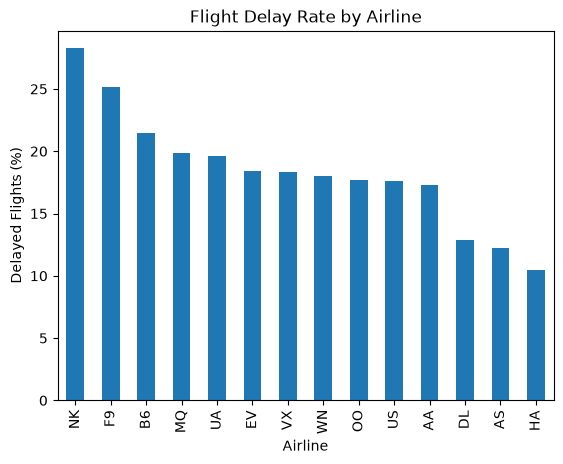

In [33]:
airline_delay_rate.plot(
    kind="bar",
    title="Flight Delay Rate by Airline",
    ylabel="Delayed Flights (%)",
    xlabel="Airline"
)

In [34]:
scheduled_hour = flights["SCHEDULED_DEPARTURE"] // 100

In [35]:
scheduled_hour.head(10)

0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
9    0
Name: SCHEDULED_DEPARTURE, dtype: int64

In [36]:
scheduled_hour.value_counts().sort_index()

SCHEDULED_DEPARTURE
0      14664
1       5159
2       1414
3        778
4        531
5     118051
6     406940
7     393947
8     381014
9     351403
10    371644
11    358084
12    355611
13    363509
14    329715
15    367760
16    334153
17    390362
18    334380
19    331338
20    259432
21    187467
22    117551
23     44172
Name: count, dtype: int64

In [37]:
hourly_delay_rate = (
    delay_status.groupby(scheduled_hour)
    .mean()
    .mul(100)
)

hourly_delay_rate

SCHEDULED_DEPARTURE
0     15.016367
1     17.774763
2     16.124470
3     16.838046
4     18.832392
5      6.761484
6      8.397798
7     10.489990
8     12.087745
9     13.386340
10    14.545640
11    15.481842
12    16.603536
13    17.992677
14    19.687306
15    20.346965
16    21.836105
17    23.196162
18    24.546923
19    24.920776
20    24.950276
21    23.066460
22    21.680802
23    18.187992
Name: ARRIVAL_DELAY, dtype: float64

In [38]:
hourly_summary = pd.DataFrame({
    "flight_count": scheduled_hour.value_counts().sort_index(),
    
    "delay_rate": hourly_delay_rate

    
})
hourly_summary

,flight_count,delay_rate
SCHEDULED_DEPARTURE,,
0,14664,15.016367
1,5159,17.774763
2,1414,16.124470
3,778,16.838046
4,531,18.832392
5,118051,6.761484
6,406940,8.397798
7,393947,10.489990
8,381014,12.087745


<Axes: title={'center': 'Flight Delay Rate by Scheduled Departure Hour'}, xlabel='Scheduled Departure', ylabel='Delayed Flights (%)'>

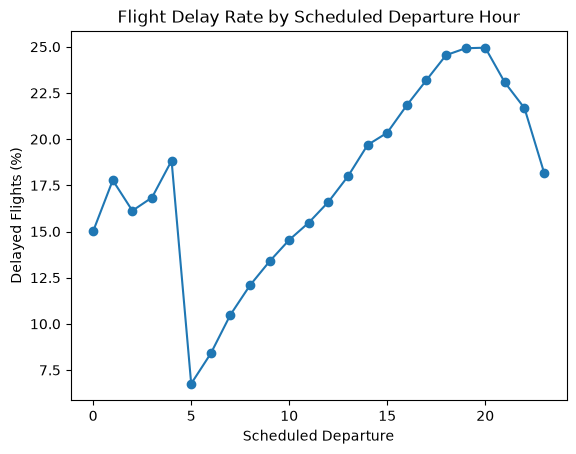

In [39]:
hourly_summary ["delay_rate"].plot(
    kind="line",
    marker="o",
    title="Flight Delay Rate by Scheduled Departure Hour",
    ylabel="Delayed Flights (%)",
    xlabel="Scheduled Departure"
)

In [40]:
origin_flight_count = flights["ORIGIN_AIRPORT"].value_counts()

origin_flight_count.head(10)

ORIGIN_AIRPORT
ATL    346836
ORD    285884
DFW    239551
DEN    196055
LAX    194673
SFO    148008
PHX    146815
IAH    146622
LAS    133181
MSP    112117
Name: count, dtype: int64

In [41]:
origin_delay_rate = (
    delay_status.groupby(flights["ORIGIN_AIRPORT"])
    .mean()
    .mul(100)
)
origin_delay_rate

ORIGIN_AIRPORT
10135    16.814159
10136    10.582011
10140    11.915888
10141    10.447761
10146    13.414634
           ...    
WRG      16.114458
WYS       6.730769
XNA      21.178498
YAK      10.725076
YUM      10.122536
Name: ARRIVAL_DELAY, Length: 930, dtype: float64

In [42]:
origin_airport_clean = flights["ORIGIN_AIRPORT"].astype(str) # noticed there is a representation mismatch hence
origin_flight_count = origin_airport_clean.value_counts() # converting the table to all string values then trying to 
                                                         # find the percentage rate of delays for each airport
origin_delay_rate = (
    delay_status.groupby(origin_airport_clean)
    .mean()
    .mul(100)
)

origin_summary = pd.DataFrame({
    "flight_count": origin_flight_count,
    "delay_rate": origin_delay_rate
})


origin_summary.head()

,flight_count,delay_rate
ORIGIN_AIRPORT,,
10135,239,16.317992
10136,201,10.447761
10140,1816,12.389868
10141,71,11.267606
10146,87,12.643678


In [43]:
flights["ORIGIN_AIRPORT"].map(type).value_counts()

ORIGIN_AIRPORT
<class 'str'>    5360327
<class 'int'>     458752
Name: count, dtype: int64

In [44]:
numeric_origins = flights.loc[
    flights["ORIGIN_AIRPORT"].map(type) == int,
    "ORIGIN_AIRPORT"
]

numeric_origins.value_counts().head(20)

ORIGIN_AIRPORT
10397    30824
13930    26117
11298    19840
11292    17135
12892    16715
14771    13353
12266    12449
14107    12194
12889    11941
13487    10027
14747     9766
10721     9607
11433     9423
11618     9079
11057     9030
13204     8468
14869     8275
12953     8132
12478     7826
10821     7569
Name: count, dtype: int64

In [45]:
origin_delay_rate = (
    delay_status.groupby(flights["ORIGIN_AIRPORT"])
    .mean()
    .mul(100)
)
origin_delay_rate

ORIGIN_AIRPORT
10135    16.814159
10136    10.582011
10140    11.915888
10141    10.447761
10146    13.414634
           ...    
WRG      16.114458
WYS       6.730769
XNA      21.178498
YAK      10.725076
YUM      10.122536
Name: ARRIVAL_DELAY, Length: 930, dtype: float64

In [46]:
origin_summary_filtered = origin_summary[
    origin_summary["flight_count"] >= 1000
]

In [47]:
origin_summary_filtered.sort_values(
    "delay_rate",
    ascending = False
).head(10)

,flight_count,delay_rate
ORIGIN_AIRPORT,,
ASE,3562,26.473891
HPN,7443,22.907430
TTN,2830,22.720848
ORD,285884,22.615816
EGE,1241,22.562450
LBE,1281,22.560500
LGA,99605,22.133427
MIA,69341,22.036025
CRW,2385,21.677149


In [48]:
origin_summary_filtered.sort_values(
    "delay_rate",
    ascending=True
).head(10)

,flight_count,delay_rate
ORIGIN_AIRPORT,,
14122,2131,6.616612
12173,3780,6.798942
10529,1714,7.001167
14869,8763,7.725665
14057,4550,7.956044
ITO,5723,8.142583
14683,2624,8.231707
13830,1823,8.283050
10397,32588,8.619737


In [49]:
flights[["ORIGIN_AIRPORT", "DESTINATION_AIRPORT"]].head(10)

,ORIGIN_AIRPORT,DESTINATION_AIRPORT
0,ANC,SEA
1,LAX,PBI
2,SFO,CLT
3,LAX,MIA
4,SEA,ANC
5,SFO,MSP
6,LAS,MSP
7,LAX,CLT
8,SFO,DFW
9,LAS,ATL


In [50]:
flights[["ORIGIN_AIRPORT", "DESTINATION_AIRPORT"]].dtypes

ORIGIN_AIRPORT         object
DESTINATION_AIRPORT    object
dtype: object

In [51]:
flights["DESTINATION_AIRPORT"].map(type).value_counts()

DESTINATION_AIRPORT
<class 'str'>    5360327
<class 'int'>     458752
Name: count, dtype: int64

In [52]:
airports = pd.read_csv("../data/raw/airports.csv")

airports.head()


,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
0,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.44040
1,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.68190
2,ABQ,Albuquerque International Sunport,Albuquerque,NM,USA,35.04022,-106.60919
3,ABR,Aberdeen Regional Airport,Aberdeen,SD,USA,45.44906,-98.42183
4,ABY,Southwest Georgia Regional Airport,Albany,GA,USA,31.53552,-84.19447


In [53]:
airports.shape

(322, 7)

In [54]:
airports.dtypes

IATA_CODE        str
AIRPORT          str
CITY             str
STATE            str
COUNTRY          str
LATITUDE     float64
LONGITUDE    float64
dtype: object

In [55]:
airports.tail()

,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
317,WRG,Wrangell Airport,Wrangell,AK,USA,56.48433,-132.36982
318,WYS,Westerly State Airport,West Yellowstone,MT,USA,44.68840,-111.11764
319,XNA,Northwest Arkansas Regional Airport,Fayetteville/Springdale/Rogers,AR,USA,36.28187,-94.30681
320,YAK,Yakutat Airport,Yakutat,AK,USA,59.50336,-139.66023
321,YUM,Yuma International Airport,Yuma,AZ,USA,32.65658,-114.60597


In [56]:
flights.loc[
    flights["ORIGIN_AIRPORT"] == 10397,
    ["ORIGIN_AIRPORT", "DESTINATION_AIRPORT"]
].head(10)

,ORIGIN_AIRPORT,DESTINATION_AIRPORT
4390925,10397,11278
4391018,10397,15304
4391021,10397,11308
4391022,10397,10685
4391023,10397,11982
4391065,10397,12992
4391067,10397,15412
4391070,10397,15919
4391073,10397,12007
4391081,10397,10731


In [57]:
flights.loc[
    flights["ORIGIN_AIRPORT"] == "ATL",
    ["ORIGIN_AIRPORT", "DESTINATION_AIRPORT"]
].head(10)

,ORIGIN_AIRPORT,DESTINATION_AIRPORT
109,ATL,IAD
304,ATL,TTN
560,ATL,DFW
729,ATL,LGA
749,ATL,IAH
815,ATL,MCO
863,ATL,CLT
868,ATL,MIA
959,ATL,FLL
1167,ATL,SLC


In [58]:
airports.columns

Index(['IATA_CODE', 'AIRPORT', 'CITY', 'STATE', 'COUNTRY', 'LATITUDE',
       'LONGITUDE'],
      dtype='str')

In [59]:
airlines = pd.read_csv("../data/raw/airlines.csv")
airlines.columns

Index(['IATA_CODE', 'AIRLINE'], dtype='str')

In [60]:
flights["ORIGIN_AIRPORT"].nunique()

930

In [61]:
flights["DESTINATION_AIRPORT"].nunique()

930

In [62]:
flights["ORIGIN_AIRPORT"].map(type).value_counts()

ORIGIN_AIRPORT
<class 'str'>    5360327
<class 'int'>     458752
Name: count, dtype: int64

In [63]:
flights["DESTINATION_AIRPORT"].map(type).value_counts()

DESTINATION_AIRPORT
<class 'str'>    5360327
<class 'int'>     458752
Name: count, dtype: int64

In [64]:
flights["ORIGIN_AIRPORT"] = flights["ORIGIN_AIRPORT"].astype(str)
flights["DESTINATION_AIRPORT"] = flights["DESTINATION_AIRPORT"].astype(str)

In [65]:
flights["ORIGIN_AIRPORT"].map(type).value_counts()

ORIGIN_AIRPORT
<class 'str'>    5819079
Name: count, dtype: int64

In [66]:
flights["DESTINATION_AIRPORT"].map(type).value_counts()


DESTINATION_AIRPORT
<class 'str'>    5819079
Name: count, dtype: int64

In [67]:
origin_flight_count.sort_index().head()


ORIGIN_AIRPORT
10135     239
10136     201
10140    1816
10141      71
10146      87
Name: count, dtype: int64

In [68]:
flights["ORIGIN_AIRPORT"].nunique()

628

In [69]:
flights["DESTINATION_AIRPORT"].nunique()

629

In [70]:
set(flights["ORIGIN_AIRPORT"]).intersection(
    set(flights["DESTINATION_AIRPORT"])
).__len__()

628

In [71]:
flights.shape

(5819079, 31)

In [72]:
flights[["ORIGIN_AIRPORT", "DESTINATION_AIRPORT"]].isna().sum()

ORIGIN_AIRPORT         0
DESTINATION_AIRPORT    0
dtype: int64

In [73]:
model_data = flights.dropna(subset=["ARRIVAL_DELAY"])

In [74]:
model_data.shape

(5714008, 31)

In [75]:
model_data["ARRIVAL_DELAY"].isna().sum()

np.int64(0)

In [76]:
model_data["DELAYED"] = (
    model_data["ARRIVAL_DELAY"] > 15
).astype(int)

In [77]:
model_data["DELAYED"].value_counts(normalize=True) * 100

DELAYED
0    82.087914
1    17.912086
Name: proportion, dtype: float64

In [78]:
model_data["DELAYED"].dtype

dtype('int64')

In [79]:
features = [
    "AIRLINE",
    "ORIGIN_AIRPORT",
    "DESTINATION_AIRPORT",
    "SCHEDULED_TIME",
    "SCHEDULED_DEPARTURE",
    "MONTH",
    "DAY",
    "DAY_OF_WEEK"
]

X = model_data[features]
y = model_data["DELAYED"]

In [80]:
X.shape

(5714008, 8)

In [81]:
y.shape

(5714008,)

In [82]:
X.head()

,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_TIME,SCHEDULED_DEPARTURE,MONTH,DAY,DAY_OF_WEEK
0,AS,ANC,SEA,205.0,5,1,1,4
1,AA,LAX,PBI,280.0,10,1,1,4
2,US,SFO,CLT,286.0,20,1,1,4
3,AA,LAX,MIA,285.0,20,1,1,4
4,AS,SEA,ANC,235.0,25,1,1,4


In [83]:
model_data["FLIGHT_DATE"] = pd.to_datetime(
    {
        "year": 2015,
        "month": model_data["MONTH"],
        "day": model_data["DAY"]
    }
)

In [84]:
model_data["FLIGHT_DATE"].min(), model_data["FLIGHT_DATE"].max()

(Timestamp('2015-01-01 00:00:00'), Timestamp('2015-12-31 00:00:00'))

In [85]:
model_data = model_data.sort_values("FLIGHT_DATE")


In [86]:
model_data[["FLIGHT_DATE", "MONTH", "DAY"]].head()


,FLIGHT_DATE,MONTH,DAY
0,2015-01-01,1,1
9361,2015-01-01,1,1
9362,2015-01-01,1,1
9363,2015-01-01,1,1
9364,2015-01-01,1,1


In [87]:
split_index = int(len(model_data) * 0.8)

In [88]:
train_data = model_data.iloc[:split_index]
test_data = model_data.iloc[split_index:]

In [89]:
train_data.shape, test_data.shape

((4571206, 33), (1142802, 33))

In [90]:
train_data["FLIGHT_DATE"].max(), test_data["FLIGHT_DATE"].min()


(Timestamp('2015-10-18 00:00:00'), Timestamp('2015-10-18 00:00:00'))

In [91]:
train_data = model_data[
    model_data["FLIGHT_DATE"] < "2015-10-18"
]

test_data = model_data[
    model_data["FLIGHT_DATE"] >= "2015-10-18"
]

In [11]:
train_data.shape, test_data.shape

NameError: name 'train_data' is not defined

In [93]:
train_data["FLIGHT_DATE"].max(), test_data["FLIGHT_DATE"].min()

(Timestamp('2015-10-17 00:00:00'), Timestamp('2015-10-18 00:00:00'))

In [94]:
train_data[["AIRLINE","ORIGIN_AIRPORT","DESTINATION_AIRPORT"]].nunique()

AIRLINE                 14
ORIGIN_AIRPORT         627
DESTINATION_AIRPORT    627
dtype: int64

In [10]:
features = [
    "AIRLINE",
    "ORIGIN_AIRPORT",
    "DESTINATION_AIRPORT",
    "SCHEDULED_TIME",
    "SCHEDULED_DEPARTURE",
    "MONTH",
    "DAY",
    "DAY_OF_WEEK"
]

X_train = train_data[features]
X_test = test_data[features]

y_train = train_data["DELAYED"]
y_test = test_data["DELAYED"]

NameError: name 'train_data' is not defined

In [96]:
categorical_features = [
    "AIRLINE",
    "ORIGIN_AIRPORT",
    "DESTINATION_AIRPORT"
]

In [97]:
from sklearn.preprocessing import OneHotEncoder

In [98]:
encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True
)

In [99]:
encoder.fit(
    X_train[categorical_features]
)

,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide <encoder_infrequent_categories>`.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a SciPy sparse matrix/arrayin ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",True
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide <encoder_infrequen

In [100]:
X_train_encoded = encoder.transform(
    X_train[categorical_features]
)

X_test_encoded = encoder.transform(
    X_test[categorical_features]
)

In [101]:
type(X_train_encoded)

scipy.sparse._csr.csr_matrix

In [102]:
numeric_features = [
    "SCHEDULED_TIME",
    "SCHEDULED_DEPARTURE",
    "MONTH",
    "DAY",
    "DAY_OF_WEEK"
]

X_train_numeric = X_train[numeric_features]
X_test_numeric = X_test[numeric_features]

In [103]:
X_train_numeric.head()

,SCHEDULED_TIME,SCHEDULED_DEPARTURE,MONTH,DAY,DAY_OF_WEEK
0,205.0,5,1,1,4
9361,140.0,1625,1,1,4
9362,265.0,1625,1,1,4
9363,210.0,1625,1,1,4
9364,210.0,1625,1,1,4


In [104]:
from scipy.sparse import hstack, csr_matrix


In [105]:
X_train_numeric_sparse = csr_matrix(X_train_numeric)
X_test_numeric_sparse = csr_matrix(X_test_numeric)

In [106]:
X_train_final = hstack([
    X_train_encoded,
    X_train_numeric_sparse
])

X_test_final = hstack([
    X_test_encoded,
    X_test_numeric_sparse
])

In [107]:
X_train_final.shape

(4565723, 1273)

In [108]:
X_test_final.shape

(1148285, 1273)

## Feature Selection

## Train-Test Split

## One-Hot Encoding

## Preparing Final Feature Matrix

In [9]:
from sklearn.model_selection import train_test_split

X_train_small, _, y_train_small, _ = train_test_split(
    X_train,
    y_train,
    train_size=500_000,
    stratify=y_train,
    random_state=42
)

NameError: name 'X_train' is not defined

In [110]:
print(X_train_small.shape)
print(y_train_small.shape)

print(y_train_small.value_counts(normalize=True) * 100)

(500000, 8)
(500000,)
DELAYED
0    81.688
1    18.312
Name: proportion, dtype: float64


In [8]:
encoder.fit(X_train_small[categorical_features])

NameError: name 'encoder' is not defined

In [7]:
X_train_cat = encoder.transform(
    X_train_small[categorical_features]
)

NameError: name 'encoder' is not defined

In [113]:
X_test_cat = encoder.transform(
    X_test[categorical_features]
)

In [114]:
X_train_num = X_train_small[numeric_features].values
X_test_num = X_test[numeric_features].values

In [6]:
from scipy.sparse import hstack

X_train_final = hstack([X_train_num, X_train_cat])
X_test_final = hstack([X_test_num, X_test_cat])

NameError: name 'X_train_num' is not defined

In [116]:
print(X_train_final.shape)
print(X_test_final.shape)

(500000, 1260)
(1148285, 1260)


In [117]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [118]:
log_reg.fit(X_train_final, y_train_small)

c:\Users\HP\Documents\flight-delay-prediction\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [119]:
y_pred = log_reg.predict(X_test_final)

print(y_pred[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [120]:
print(y_test.iloc[:20].values)

[0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0]


In [121]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8368


In [122]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[960831     28]
 [187415     11]]


In [123]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      1.00      0.91    960859
           1       0.28      0.00      0.00    187426

    accuracy                           0.84   1148285
   macro avg       0.56      0.50      0.46   1148285
weighted avg       0.75      0.84      0.76   1148285



Testing out a New Model to compare with the Logic Regression

In [124]:
from sklearn.ensemble import RandomForestClassifier

In [125]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [126]:
rf_model.fit(X_train_final, y_train_small)

KeyboardInterrupt: 

In [ ]:
rf_pred = rf_model.predict(X_test_final)

In [ ]:
print(rf_pred[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [ ]:
rf_accuracy = accuracy_score(y_test, rf_pred)

In [ ]:
print(f"Random Forest Accuracy:{rf_accuracy:.4f}")

Random Forest Accuracy:0.8344


In [ ]:
rf_confusion_matrix = confusion_matrix(y_test, rf_pred)

print(rf_confusion_matrix)

[[956725   4134]
 [186008   1418]]


In [ ]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.84      1.00      0.91    960859
           1       0.26      0.01      0.01    187426

    accuracy                           0.83   1148285
   macro avg       0.55      0.50      0.46   1148285
weighted avg       0.74      0.83      0.76   1148285



After testing the Random forest model I and with the understanding that It can be improved I choose to try and improve it first before testing another model

In [3]:
from sklearn.ensemble import RandomForestClassifier

rf_balanced = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

In [5]:
rf_balanced.fit(X_train_final, y_train_small)

NameError: name 'X_train_final' is not defined

In [ ]:
rf_balanced_pred = rf_balanced.predict(X_test_final)

In [ ]:
rf_balanced_accuracy = accuracy_score(y_test, rf_balanced_pred)

print(f"Balanced Random Forest Accuracy: {rf_balanced_accuracy:.4f}")


Balanced Random Forest Accuracy: 0.8201


In [ ]:
cm_balanced = confusion_matrix(y_test, rf_balanced_pred)

print(cm_balanced)

[[933009  27850]
 [178733   8693]]


In [ ]:
print(classification_report(y_test, rf_balanced_pred))

              precision    recall  f1-score   support

           0       0.84      0.97      0.90    960859
           1       0.24      0.05      0.08    187426

    accuracy                           0.82   1148285
   macro avg       0.54      0.51      0.49   1148285
weighted avg       0.74      0.82      0.77   1148285



In [ ]:
feature_importance = rf_balanced.feature_importances_

print(feature_importance)

[1.21592299e-01 1.75189821e-01 1.03092728e-01 ... 4.80036619e-04
 2.60913802e-05 9.67865101e-05]


In [ ]:
encoded_feature_names = encoder.get_feature_names_out(categorical_features)

all_feature_names = list(numeric_features) + list(encoded_feature_names)

In [ ]:
encoded_feature_names = encoder.get_feature_names_out(categorical_features)

all_feature_names = list(numeric_features) + list(encoded_feature_names)

importance_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": rf_balanced.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(20)

,Feature,Importance
1,SCHEDULED_DEPARTURE,0.175190
3,DAY,0.170430
0,SCHEDULED_TIME,0.121592
2,MONTH,0.103093
4,DAY_OF_WEEK,0.093331
8,AIRLINE_DL,0.004402
18,AIRLINE_WN,0.004044
5,AIRLINE_AA,0.003630
1024,DESTINATION_AIRPORT_DEN,0.003491
494,ORIGIN_AIRPORT_LAX,0.003194


In [ ]:
monthly_delay_rate = (
    model_data.groupby("MONTH")["DELAYED"]
    .mean()
    .mul(100)
)

monthly_delay_rate

MONTH
1     20.219775
2     22.516147
3     18.643348
4     16.436690
5     17.635982
6     22.733424
7     20.211943
8     18.008318
9     12.449557
10    11.853305
11    14.615230
12    19.865792
Name: DELAYED, dtype: float64

<Axes: title={'center': 'Delay Rate by Month'}, xlabel='Month', ylabel='Delayed Flights (%)'>

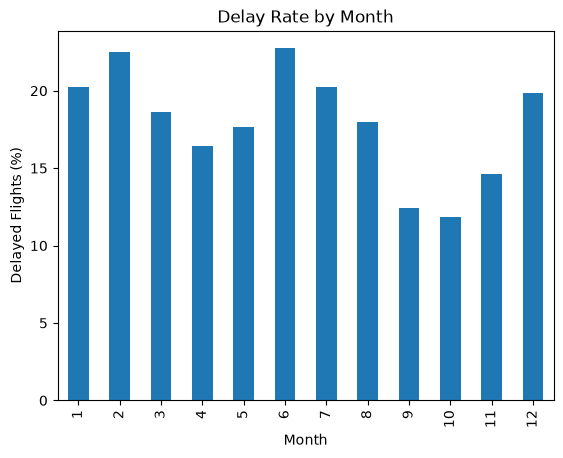

In [ ]:
monthly_delay_rate.plot(
    kind="bar",
    title="Delay Rate by Month",
    ylabel="Delayed Flights (%)",
    xlabel="Month"
)

In [ ]:
weekday_delay_rate = (
    model_data.groupby("DAY_OF_WEEK")["DELAYED"]
    .mean()
    .mul(100)
)

weekday_delay_rate

DAY_OF_WEEK
1    19.069867
2    17.614839
3    17.501975
4    19.252558
5    18.433920
6    15.376842
7    17.627452
Name: DELAYED, dtype: float64

<Axes: title={'center': 'Delay Rate by Day of Week'}, xlabel='Day of Week', ylabel='Delayed Flights (%)'>

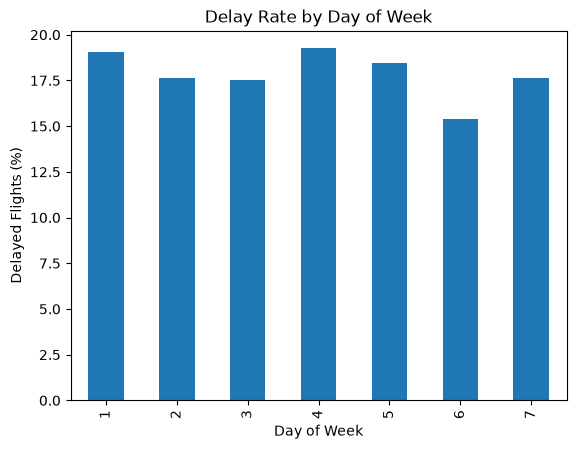

In [ ]:
weekday_delay_rate.plot(
    kind="bar",
    title="Delay Rate by Day of Week",
    ylabel="Delayed Flights (%)",
    xlabel="Day of Week"
)

<Axes: title={'center': 'Delay Rate by Day of Month'}, xlabel='Day', ylabel='Delayed Flights (%)'>

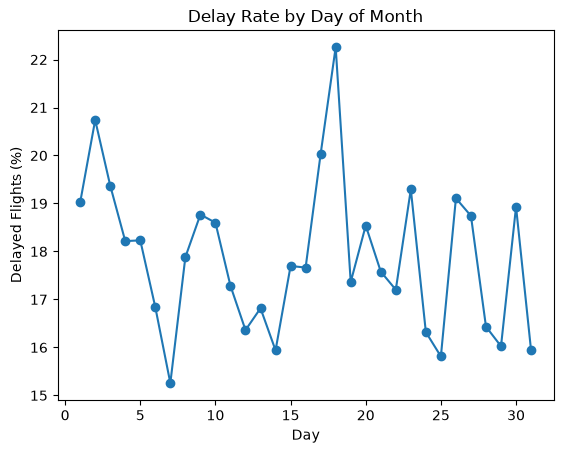

In [ ]:
day_delay_rate = (
    model_data.groupby("DAY")["DELAYED"]
    .mean()
    .mul(100)
)

day_delay_rate

day_delay_rate.plot(
    kind="line",
    marker="o",
    title="Delay Rate by Day of Month",
    ylabel="Delayed Flights (%)",
    xlabel="Day"
)


In [127]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

xgb_model.fit(
    X_train_final,
    y_train_small
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [130]:
y_pred_xgb = xgb_model.predict(X_test_final)

accuracy = accuracy_score(y_test, y_pred_xgb)

print(f"XGBoost Accuracy: {accuracy:.4f}")

y_pred_xgb = xgb_model.predict(X_test_final)


cm = confusion_matrix(y_test, y_pred_xgb)

print(cm)


print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.8368
[[960809     50]
 [187393     33]]
              precision    recall  f1-score   support

           0       0.84      1.00      0.91    960859
           1       0.40      0.00      0.00    187426

    accuracy                           0.84   1148285
   macro avg       0.62      0.50      0.46   1148285
weighted avg       0.77      0.84      0.76   1148285



In [1]:
y_prob_balanced = rf_balanced.predict_proba(X_test_final)[:, 1]

NameError: name 'rf_balanced' is not defined